### Graphène (Papier Sergei)

Si on utilise du graphène, la bande de dispersion s'écrit alors $\varepsilon(p) = v_F p$.
Regardons à nouveaux les moments obtenus avec une bande de cette forme.
On change le paramètre ${v_F}$ qui vaut $0.1$ dans le graphène.

In [2]:
# Packages ------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from pyhamsys import HamSys, solve_ivp_sympext, Parameters

0.5976704777718237
Resultat etrange pour le solveurs, A CORRIGER


        Computation finished in 0 seconds


Comparaison des méthodes avec vF =  0.1 


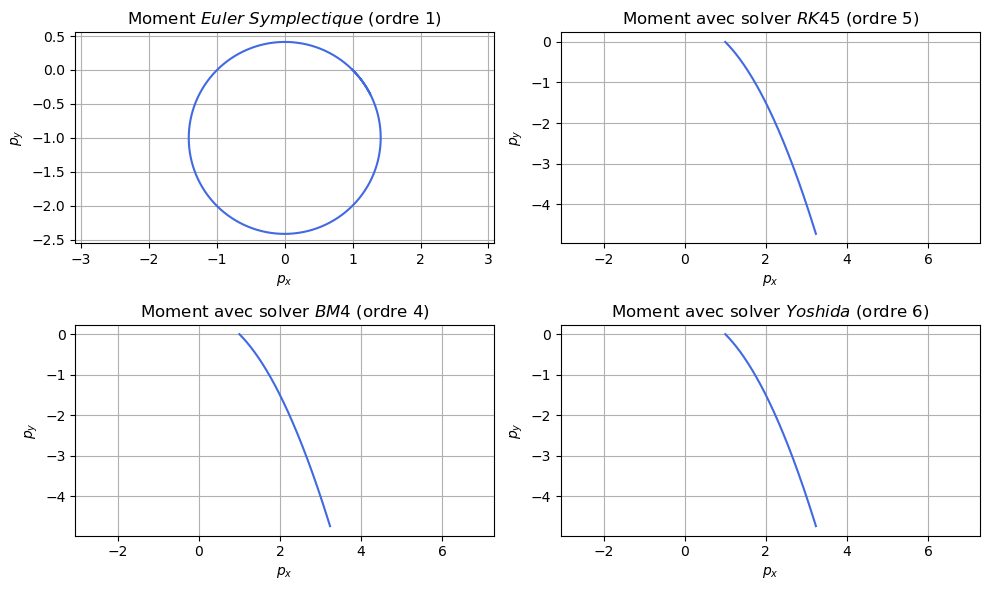

In [15]:
# Paramètres ---------------------------------------------------------------------

P = np.array([1, 0])
e = 1
B = 0.7
vF = 1
c = 1
vd = 0.1 #5.0
vF_liste = [0.1] #0.8

def W_graphene(P):
   return varepsilon_graphene(P) + vd * P[1]

def omega_c(W):
   return (e * B / c) * ( vF**2 / W_graphene(P)) * (1 - vd/vF)**(3/2)



# ----------------------------------------------------------------------------------------------------
def varepsilon_graphene(p):
    px = p[0]
    py = p[1]
    return  vF * np.sqrt((px**2 + py**2)) 

def ES_graphene(deltaT, T, P, e , B, c, vF):
    G = deltaT * e * B * vF**2 / (c * varepsilon_graphene(P))
    Iteration_matrix = [[1 - G**2, G], [-G, 1]]
    Drift_matrix = [deltaT * e * B * vd /c, 0]
    P_trajectory = [P]
    t = 0
    while ( t + deltaT < T):
        P = Iteration_matrix @ P + Drift_matrix
        t += deltaT
        P_trajectory.append(P)
    deltaT = T - t
    Drift_matrix = [deltaT * e * B * vd /c, 0]
    P = Iteration_matrix @ P + Drift_matrix
    return np.array(P_trajectory)
   
def p_system(t, P): #resolution papier pour bande linéaire
 G =  e * B  / c
 q, p = np.split(P, 2)
 y0 = G * ((vF**2 * p / varepsilon_graphene(P)) + vd)
 y1 = -G * (vF**2 * q / varepsilon_graphene(P))
 return np.concatenate((y0 , y1), axis=None)
# ------------ A CORRIGER --------------------------------------
T = 15 * 2 * np.pi / 1#omega_c(W_graphene(P))
deltaT = 0.05
number_iter = T / deltaT
time_range = np.linspace(0, T , int(number_iter)) 

print(omega_c(W_graphene(P)))
print('Resultat etrange pour le solveurs, A CORRIGER')
#---------------------------------------------------------------------------------------------------
hs = HamSys(ndof=1)
for i, vF in enumerate(vF_liste):
    hs.y_dot = p_system # choix du système
    sol_BM4 = solve_ivp_sympext(hs, t_span=(0,T), y0=P, params=Parameters(step=deltaT, solver='BM4'))
    # sol_Verlet = solve_ivp_sympext(hs, t_span=(0,T), y0=P, params=Parameters(step=deltaT, solver='Verlet'))
    sol_Yoshida = solve_ivp_sympext(hs, t_span=(0,T), y0=P, params=Parameters(step=deltaT, solver='Yos6'))

    Moment_ES = ES_graphene(deltaT, T, P, e, B, c, vF)

    sol_RK45 = hs.integrate( P, time_range, params=Parameters(step=deltaT, solver='RK45'))
# Plot ------------------------------------------

    print(f'Comparaison des méthodes avec vF =  {vF} ')
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(10,6))

    ax1.plot(Moment_ES[:, 0], Moment_ES[:,1], color='royalblue',label='ES')
    ax1.set_xlabel(r'$p_x$')
    ax1.set_ylabel(r'$p_y$')
    ax1.set_title(r'Moment $Euler \ Symplectique$ (ordre 1)')  

    # ax1.plot(sol_Verlet.y[0], sol_Verlet.y[1], color='royalblue',label='ES')
    # ax1.set_xlabel(r'$p_x$')
    # ax1.set_ylabel(r'$p_y$')
    # ax1.set_title(r'Moment solver $Verlet$ (ordre 2)') 


    ax2.plot(sol_RK45.y[0], sol_RK45.y[1], color='royalblue')
    ax2.set_xlabel(r'$p_x$')
    ax2.set_ylabel(r'$p_y$')
    ax2.set_title(r'Moment avec solver $RK45$ (ordre 5)')

    ax3.plot(sol_BM4.y[0], sol_BM4.y[1], color='royalblue')
    ax3.set_xlabel(r'$p_x$')
    ax3.set_ylabel(r'$p_y$')
    ax3.set_title(r'Moment avec solver $BM4$ (ordre 4)')

    ax4.plot(sol_Yoshida.y[0], sol_Yoshida.y[1], color='royalblue')
    ax4.set_xlabel(r'$p_x$')
    ax4.set_ylabel(r'$p_y$')
    ax4.set_title(r'Moment avec solver $Yoshida$ (ordre 6)')
    ax1.grid(), ax2.grid(), ax3.grid(), ax4.grid()
    ax1.axis('equal'), ax2.axis('equal'), ax3.axis('equal'), ax4.axis('equal')

    plt.tight_layout()
    plt.show()